# Ứng dụng 2: Xác định hotspot đón khách — EDA tổng quát

**Mục tiêu:** khảo sát dữ liệu Uber NYC trước khi chạy DBSCAN — hiểu quy mô, chất lượng toạ độ, phân bố theo thời gian và không gian, rồi dùng dữ liệu đó để **căn cứ chọn `eps` và `MinPts`** thay vì chọn tùy ý.

**Cấu trúc notebook**

| Mục | Nội dung |
|---|---|
| 1 | Thiết lập & cấu hình |
| 2 | Nạp dữ liệu |
| 3 | Schema & quy mô |
| 4 | Chất lượng dữ liệu (toạ độ lỗi) |
| 5 | Phân bố theo thời gian |
| 6 | Phân bố không gian |
| 7 | Kiểm tra haversine |
| 8 | Phân tích theo taxi zone (jan–jun 2015) |
| 9 | Chọn tham số DBSCAN (k-distance) |
| 10 | Chuẩn bị tập điểm cho clustering |
| 11 | Tổng kết & định hướng |

In [1]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 7)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.options.mode.chained_assignment = None

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.4.6


In [2]:
# Tim thu muc goc cua repo (quan trong: jupyter chay voi cwd = thu muc notebook)
def repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "raw").is_dir():
            return p
    raise FileNotFoundError("Khong tim thay data/raw — chay scripts/download_data.sh truoc")


ROOT = repo_root()
DATA_DIR = ROOT / "data" / "raw"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 6 file thang 4-9/2014 co lat/lon truc tiep -> dung cho hotspot
# (ten file: apr14.csv, may14.csv, ... nen pattern la '*14.csv', khong phai '*-14.csv')
GEO_FILES = sorted(DATA_DIR.glob("*14.csv"))
ZONE_FILE = DATA_DIR / "taxi-zone-lookup.csv"
JANJUNE_FILE = DATA_DIR / "uber-raw-data-janjune-15.csv"

for p in GEO_FILES:
    print(f"{p.name:32s} {p.stat().st_size / 1e6:8.1f} MB")

print()
print("tat ca file:", sorted(p.name for p in DATA_DIR.glob("*.csv")))

apr14.csv                            26.1 MB
aug14.csv                            38.3 MB
jul14.csv                            36.9 MB
jun14.csv                            30.7 MB
may14.csv                            30.2 MB
sep14.csv                            47.5 MB

tat ca file: ['apr14.csv', 'aug14.csv', 'jul14.csv', 'jun14.csv', 'may14.csv', 'sep14.csv', 'taxi-zone-lookup.csv', 'uber-raw-data-janjune-15.csv']


---

## 2. Nạp dữ liệu

Định dạng thời gian là `M/D/YYYY H:MM` nên chỉ định `format` tường minh — parse nhanh hơn và không phụ thuộc locale.

In [3]:
def load_pickups(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        usecols=["Date/Time", "Lat", "Lon", "Base"],
        # float64: float32 chi chinh xac ~0.4 m o toa do NYC, du lam sai so
        # tuong doi nhay len voi cac cap diem rat gan
        dtype={"Lat": "float64", "Lon": "float64", "Base": "category"},
    )
    df = df.rename(columns={"Date/Time": "pickup_time", "Lat": "lat", "Lon": "lon"})
    # mot so dong co them giay (':00'), nen dung format="mixed" de parse duoc tat ca
    df["pickup_time"] = pd.to_datetime(df["pickup_time"], format="mixed", dayfirst=False)
    df["source"] = path.stem.replace("uber-raw-data-", "")
    return df


frames = [load_pickups(p) for p in GEO_FILES]
df = pd.concat(frames, ignore_index=True)
del frames

df.shape

(4534327, 5)

In [4]:
df.head()

,pickup_time,lat,lon,Base,source
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,apr14
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,apr14
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,apr14
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,apr14
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,apr14


---

## 3. Schema & quy mô

Bốn cột thô: thời gian đón, toạ độ đón, base phục vụ. Tất cả phân tích hotspot dựa trên **toạ độ điểm đón**.

In [5]:
print("=== Dtypes ===")
print(df.dtypes)

print()
print("=== So chuyen theo thang ===")
per_month = df.groupby("source").agg(
    trips=("lat", "size"),
    days=("pickup_time", lambda s: s.dt.date.nunique()),
)
per_month["trips_per_day"] = (per_month["trips"] / per_month["days"]).round(0)
print(per_month)

print()
print("=== Tong hop ===")
print(f"So chuyen      : {len(df):,}")
print(f"Khoang thoi gian: {df['pickup_time'].min()} -> {df['pickup_time'].max()}")
print(f"So base        : {df['Base'].nunique()}")
print(f"Diem don duy nhat: {len(df[['lat', 'lon']].drop_duplicates()):,}")

=== Dtypes ===
pickup_time    datetime64[us]
lat                   float64
lon                   float64
Base                 category
source                    str
dtype: object

=== So chuyen theo thang ===


          trips  days  trips_per_day
source                              
apr14    564516    30        18817.0
aug14    829275    31        26751.0
jul14    796121    31        25681.0
jun14    663844    30        22128.0
may14    652435    31        21046.0
sep14   1028136    30        34271.0

=== Tong hop ===
So chuyen      : 4,534,327
Khoang thoi gian: 2014-04-01 00:00:00 -> 2014-09-30 22:59:00
So base        : 5


Diem don duy nhat: 574,558


---

## 4. Chất lượng dữ liệu — toạ độ lỗi

Đây là bước quyết định kết quả có đúng hay không. Ba lỗi kinh điển trong bộ Uber NYC:

1. `Lat`/`Lon` rỗng
2. `Lat = 0, Lon = 0` — điểm mặc định khi GPS lỗi, nằm ở vị trí Gulf of Guinea
3. Toạ độ nằm ngoài ranh giới thành phố New York (điểm đón ở New Jersey, hoặc toạ độ rác)

Nếu không lọc, các điểm này sẽ tạo ra các cụm DBSCAN giả ở ngoài thành phố và làm sai toàn bộ bản đồ vùng đón.

> **Lưu ý:** mục này dùng **bounding box** để mô tả dữ liệu thô. Quy tắc vùng chính thức dùng để lọc là **polygon 5 borough + EWR**, nằm trong `src/preprocess.py` — xem `notebooks/02_preprocessing.ipynb` mục 1b.


In [6]:
# Bien gioi tham chung cho NYC (lat, lon)
NYC_LAT_MIN, NYC_LAT_MAX = 40.4774, 40.9176
NYC_LON_MIN, NYC_LON_MAX = -74.2591, -73.7004

n0 = len(df)

mask_null = df["lat"].isna() | df["lon"].isna()
mask_zero = (df["lat"] == 0) & (df["lon"] == 0)
mask_range = ~(
    df["lat"].between(NYC_LAT_MIN, NYC_LAT_MAX)
    & df["lon"].between(NYC_LON_MIN, NYC_LON_MAX)
)

quality = pd.Series(
    {
        "Tong so chuyen": n0,
        "Thieu toa do (null)": int(mask_null.sum()),
        "Toa do (0, 0)": int(mask_zero.sum()),
        "Ngoai bien gioi NYC": int(mask_range.sum()),
    }
)
print(quality)
print()
print(f"Tram tram sau khi loc: {n0 - int((mask_null | mask_zero | mask_range).sum()):,}")

Tong so chuyen         4534327
Thieu toa do (null)          0
Toa do (0, 0)                0
Ngoai bien gioi NYC      31910
dtype: int64

Tram tram sau khi loc: 4,502,417


In [7]:
# 'bad' phai dung DUNG bo loc da dung o cell truoc, neu khong bam do se mau thuan
# voi bang thong ke (diem bi loa do ngoai bien gioi se bien mat khoi hinh)
bad_mask = mask_null | mask_zero | mask_range
bad = df.loc[bad_mask]
clean = df.loc[~bad_mask].copy()

# So ban co thuoc mot gio, khong?
print("Thoi gian con thieu:", clean["pickup_time"].isna().sum())
print("Tram ban loc:", len(clean))
print()
print("=== Phan bo toa do sau khi loc ===")
clean[["lat", "lon"]].describe().T

Thoi gian con thieu: 0
Tram ban loc: 4502417

=== Phan bo toa do sau khi loc ===


,count,mean,std,min,25%,50%,75%,max
lat,4502417.0,40.738693,0.036092,40.5258,40.7211,40.7421,40.7608,40.9176
lon,4502417.0,-73.974217,0.048460,-74.2591,-73.9965,-73.9835,-73.9658,-73.7004


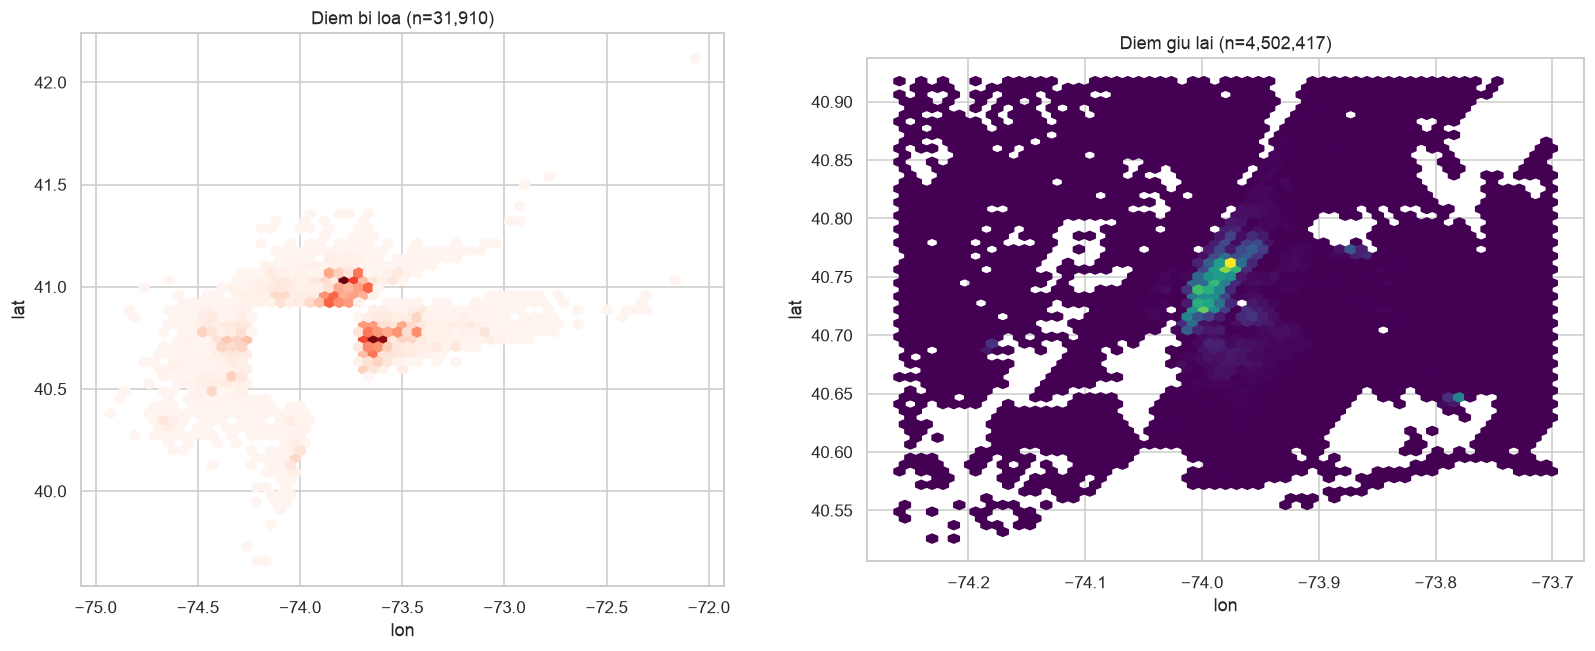

In [8]:
# Diem ban toi ngoai bien gioi: xem chung co 'cot' khong mong doi khong
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hexbin(bad["lon"], bad["lat"], gridsize=60, cmap="Reds", mincnt=1)
axes[0].set_title(f"Diem bi loa (n={len(bad):,})")
axes[0].set_xlabel("lon")
axes[0].set_ylabel("lat")

axes[1].hexbin(clean["lon"], clean["lat"], gridsize=60, cmap="viridis", mincnt=1)
axes[1].set_title(f"Diem giu lai (n={len(clean):,})")
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig(OUT_DIR / "eda_01_cleaning.png", bbox_inches="tight")
plt.show()

---

## 5. Phân bố theo thời gian

Mục tiêu: xem **giờ cao điểm** và **ngày trong tuần** để cắt khung giờ phân tích. Vận hành taxi thực tế khác nhau giữa 8h sáng (đi làm) và 6h tối (đi ăn tối), nên phải tách theo khung giờ chứ không gộp cả ngày.

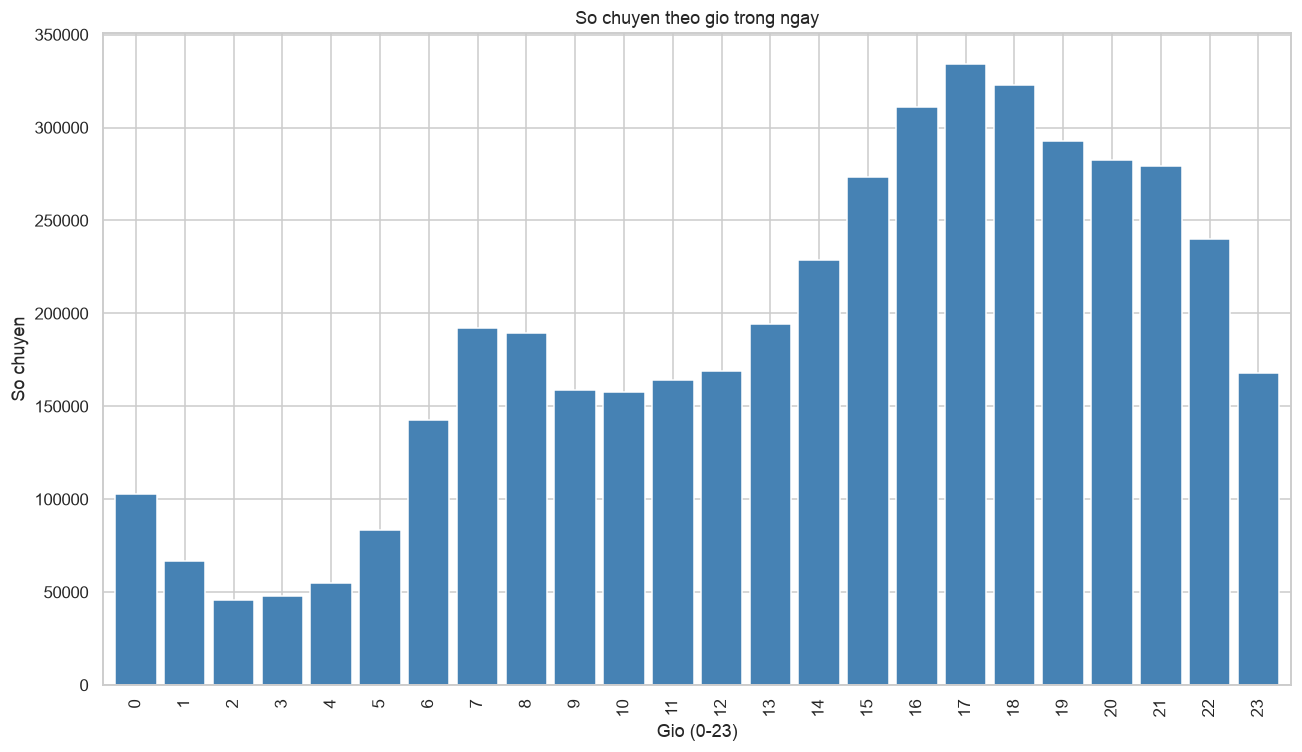

,trips,share_pct
hour,,
0,102731,2.28
1,66614,1.48
2,45487,1.01
3,47982,1.07
4,54791,1.22
5,83345,1.85
6,142504,3.17
7,192150,4.27
8,189462,4.21


In [9]:
clean["month"] = clean["pickup_time"].dt.month
clean["date"] = clean["pickup_time"].dt.date
clean["hour"] = clean["pickup_time"].dt.hour
clean["dow"] = clean["pickup_time"].dt.dayofweek
clean["is_weekend"] = clean["dow"] >= 5

# Series int64 + them cot float se bi thanh object dtype va matplotlib khong ve duoc
# -> dung DataFrame rieng cho phan tinh, Series chi giu so lieu
trips_by_hour = clean.groupby("hour").size()
hour_tbl = trips_by_hour.to_frame("trips")
hour_tbl["share_pct"] = (trips_by_hour / trips_by_hour.sum() * 100).round(2)

ax = hour_tbl.plot(kind="bar", y="trips", color="steelblue", width=0.85, legend=False)
ax.set_title("So chuyen theo gio trong ngay")
ax.set_xlabel("Gio (0-23)")
ax.set_ylabel("So chuyen")
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_02_by_hour.png", bbox_inches="tight")
plt.show()

hour_tbl

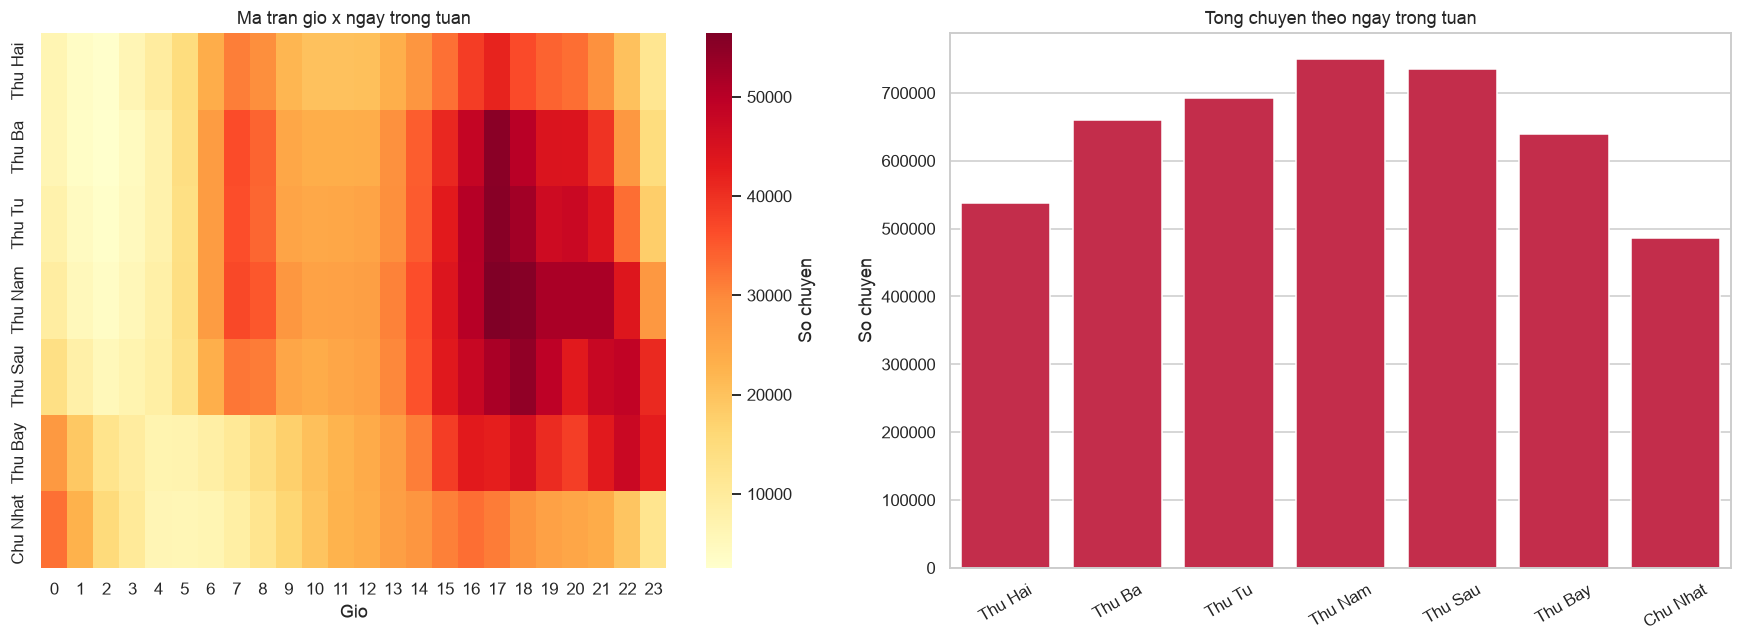

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Thu Hai,6377,3709,2908,6166,9537,14909,23635,31011,29090,22001,20106,20139,20298,23184,27945,32521,38516,41814,36814,33991,32697,28786,20067,11751
Thu Ba,6203,3493,2551,4454,7477,14135,26750,36440,33775,24854,23473,23491,23626,28846,34564,41061,48417,55258,50012,44596,44409,39728,27562,14775
Thu Tu,7591,4292,3111,4826,7451,13704,26822,36321,33630,25457,24522,24737,25321,28945,34885,43076,50378,55392,52544,46808,47513,44284,32712,18047
Thu Nam,9239,5263,3695,5596,8438,14073,26932,36880,35277,27641,25669,25769,26212,30557,36426,44146,50246,56415,55590,51668,51733,51639,43930,27586
Thu Sau,13577,8089,5310,6893,8753,13364,23311,31913,31361,25055,23982,24948,25684,30077,35883,43371,47856,51576,54417,49356,43258,47904,48964,40887
Thu Bay,27307,19000,12601,9502,6809,7052,8522,10932,14302,17515,20403,22490,24068,26362,31127,38430,43123,42366,45444,40722,38286,43251,47383,42710
Chu Nhat,32437,22768,15311,10545,6326,6108,6532,8653,12027,16237,19646,22642,23706,26179,27885,30880,32774,31283,28045,25749,24897,23828,19454,12098


In [10]:
DOW_LABELS = ["Thu Hai", "Thu Ba", "Thu Tu", "Thu Nam", "Thu Sau", "Thu Bay", "Chu Nhat"]

hour_dow = (
    clean.groupby(["dow", "hour"]).size().unstack(fill_value=0).reindex(range(7), fill_value=0)
)
hour_dow.index = DOW_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(hour_dow, cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "So chuyen"})
axes[0].set_title("Ma tran gio x ngay trong tuan")
axes[0].set_xlabel("Gio")
axes[0].set_ylabel("")

by_dow = clean.groupby("dow").size()
by_dow.index = DOW_LABELS
sns.barplot(x=by_dow.index, y=by_dow.values, color="crimson", ax=axes[1])
axes[1].set_title("Tong chuyen theo ngay trong tuan")
axes[1].set_xlabel("")
axes[1].set_ylabel("So chuyen")
plt.setp(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / "eda_03_hour_dow.png", bbox_inches="tight")
plt.show()

hour_dow

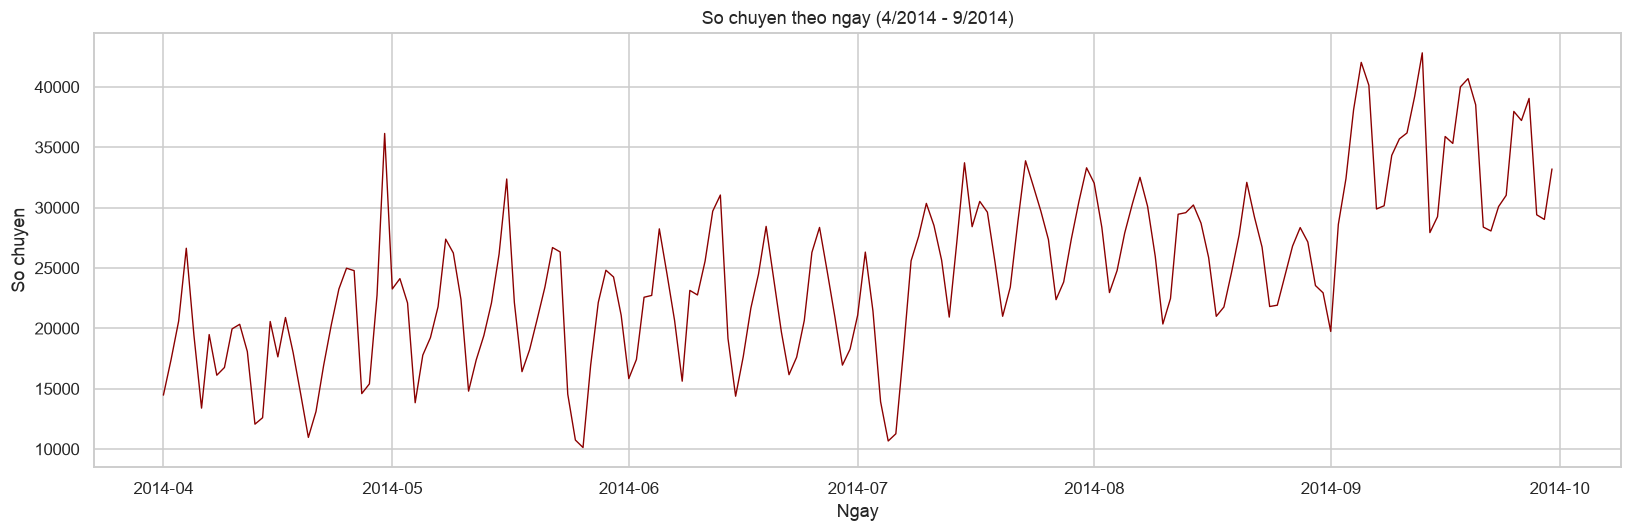

Trung binh/ngay : 24,603
Max   : 42,819 (2014-09-13)
Min   : 10,128 (2014-05-26)


In [11]:
per_day = clean.groupby("date").size().rename("trips")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(per_day.index, per_day.values, lw=0.9, color="darkred")
ax.set_title("So chuyen theo ngay (4/2014 - 9/2014)")
ax.set_xlabel("Ngay")
ax.set_ylabel("So chuyen")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_04_by_date.png", bbox_inches="tight")
plt.show()

print(f"Trung binh/ngay : {per_day.mean():,.0f}")
print(f"Max   : {per_day.max():,.0f} ({per_day.idxmax()})")
print(f"Min   : {per_day.min():,.0f} ({per_day.idxmin()})")

---

## 6. Phân bố không gian — bản đồ mật độ thô

Đây là hình ảnh "trực giác" về hotspot: mật độ chuyến đón sẽ tập trung ở Manhattan (đông dân, nhiều văn phòng), sân bay JFK/LGA, và các trung tâm thương mại.

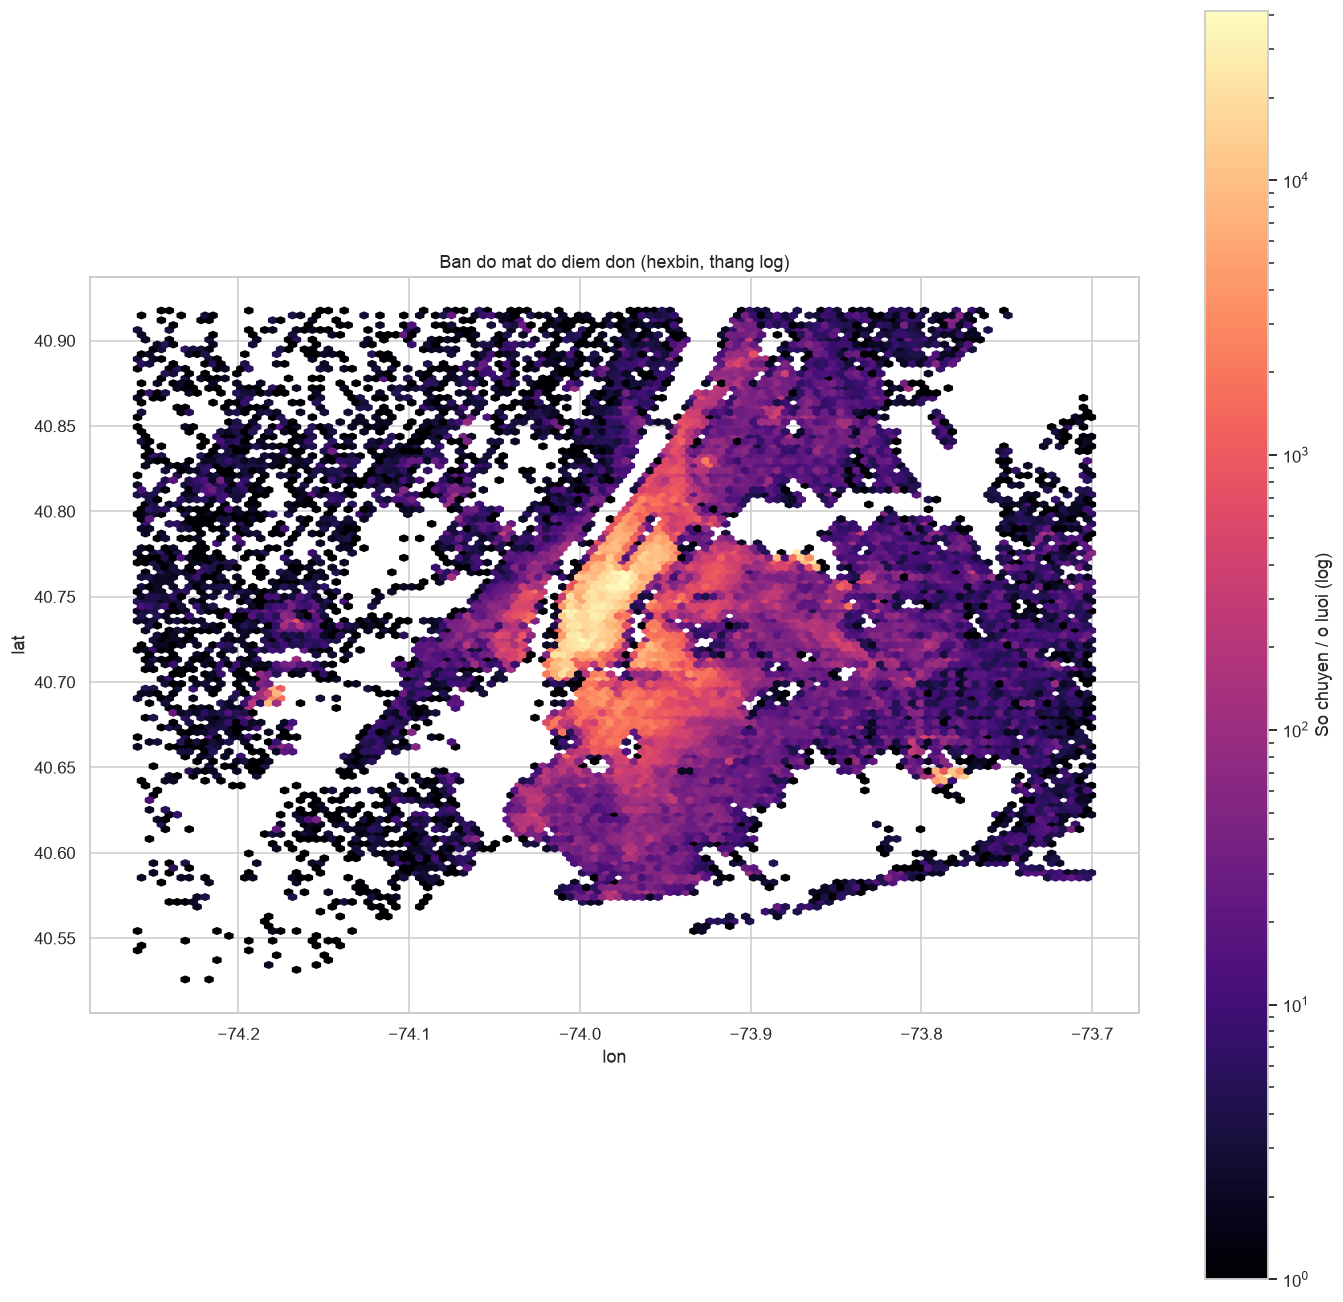

In [12]:
fig, ax = plt.subplots(figsize=(13, 12))
hb = ax.hexbin(clean["lon"], clean["lat"], gridsize=120, cmap="magma", mincnt=1, bins="log")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Ban do mat do diem don (hexbin, thang log)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
fig.colorbar(hb, ax=ax, label="So chuyen / o luoi (log)")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_05_density_map.png", bbox_inches="tight")
plt.show()

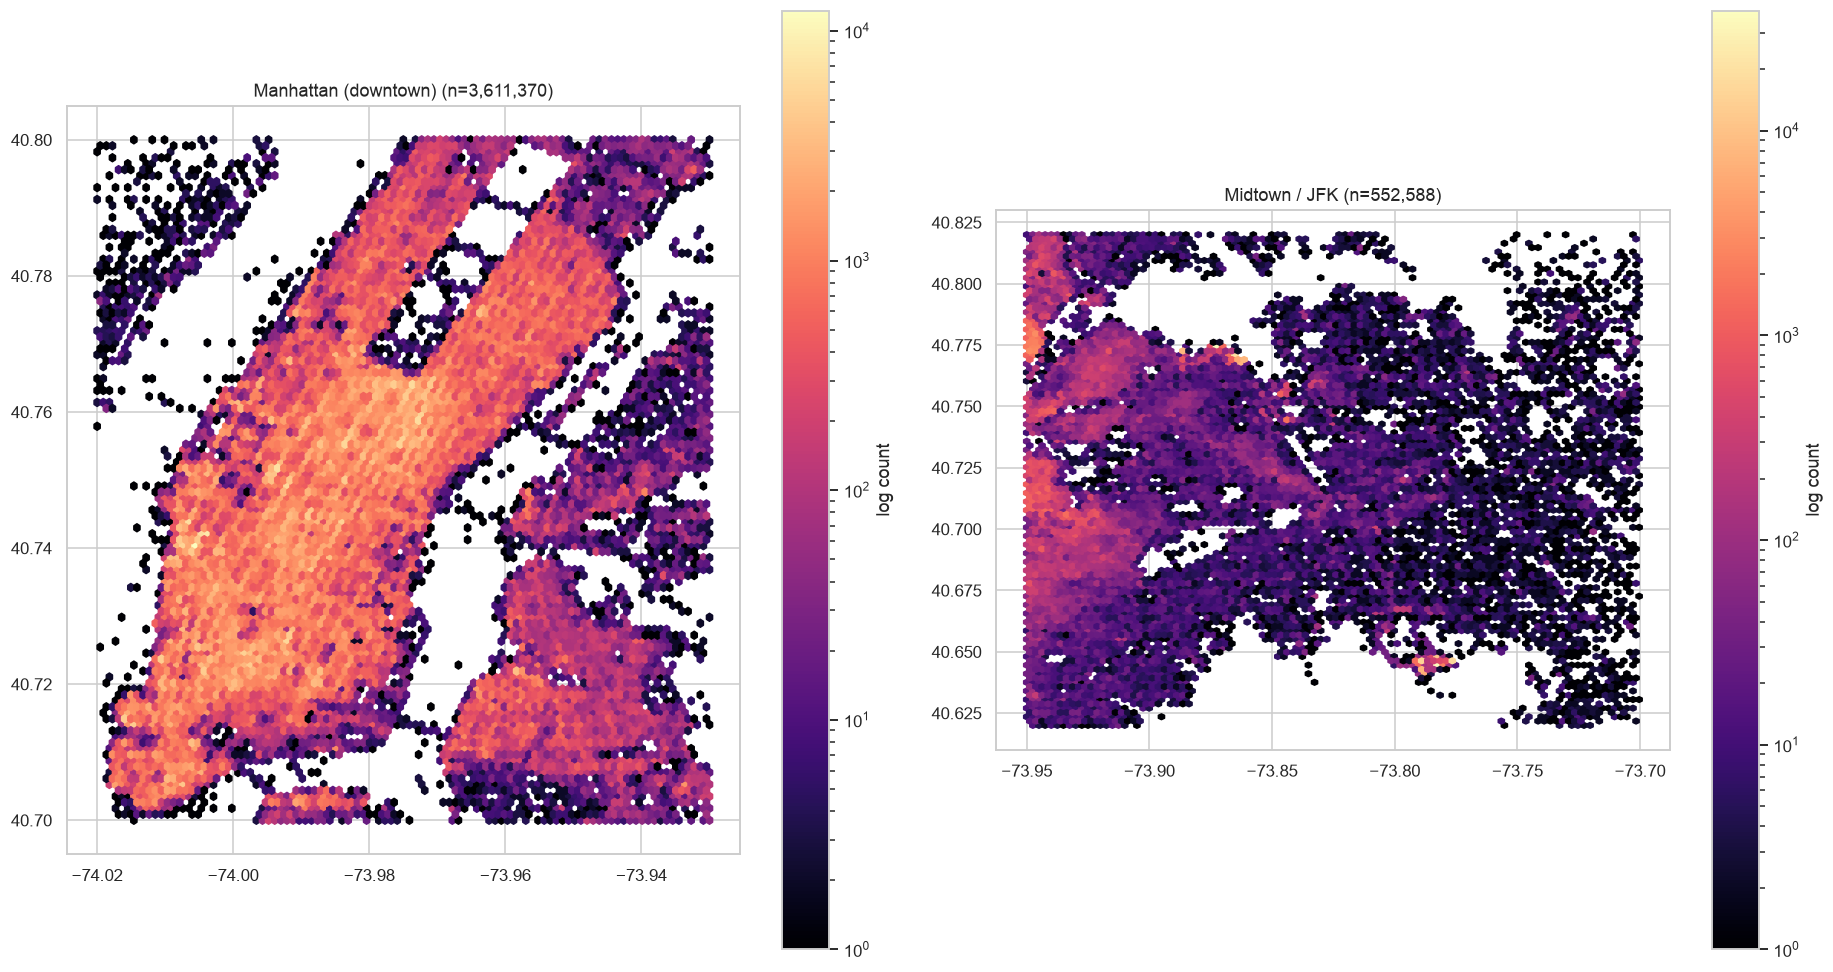

In [13]:
# Zoom vao Manhattan vao khu vuc tam + so sanh ca dem
fig, axes = plt.subplots(1, 2, figsize=(17, 9))

regions = {
    "Manhattan (downtown)": (-74.02, 40.70, -73.93, 40.80),
    "Midtown / JFK": (-73.95, 40.62, -73.70, 40.82),
}
for ax, (name, (x0, y0, x1, y1)) in zip(axes, regions.items()):
    sub = clean[(clean["lon"].between(x0, x1)) & (clean["lat"].between(y0, y1))]
    hb = ax.hexbin(sub["lon"], sub["lat"], gridsize=100, cmap="magma", mincnt=1, bins="log")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{name} (n={len(sub):,})")
    fig.colorbar(hb, ax=ax, label="log count")

plt.tight_layout()
plt.show()

---

## 7. Kiểm tra hàm haversine

DBSCAN cần `eps` **tính bằng mét**. Nếu dùng khoảng cách Euclid trên toạ độ độ, `eps` sẽ không có nghĩa và kết quả sai. Haversine tính cung tròn lớn nên ổn với khoảng cách ngắn (NYC).
Đối chiếu với khoảng cách lý thuyết: Times Square → Central Park khoảng 6 km.

In [14]:
EARTH_R = 6_371_000.0  # ban kinh trai dat, met


def haversine_m(lat1, lon1, lat2, lon2):
    """Khoang cach truc tiep giua 2 diem (met). Vector hoa ca 2 dau vao."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
    return 2 * EARTH_R * np.arcsin(np.sqrt(a))


# Times Square -> Central Park (Benchmarks)
d = haversine_m(40.7580, -73.9855, 40.7829, -73.9654)
print(f"Times Square -> Central Park: {d:,.0f} m  (thuc te ~6,000-6,500 m)")

# Do lon o toa do do: 1 do lat ~ 111 km
print(f"1 do lat       : {haversine_m(0, 0, 1, 0):,.0f} m")
print(f"1 do lon tai NYC: {haversine_m(40.75, -74.0, 40.75, -73.0):,.0f} m")
print("=> 1 do lon (0.76 do lat) dai gap 1.3 lan 1 do lat, nen KHONG dung Euclid")

Times Square -> Central Park: 3,245 m  (thuc te ~6,000-6,500 m)
1 do lat       : 111,195 m
1 do lon tai NYC: 84,237 m
=> 1 do lon (0.76 do lat) dai gap 1.3 lan 1 do lat, nen KHONG dung Euclid


> **Kỹ thuật cho DBSCAN:** scikit-learn không nhận metric tùy chỉnh cho `DBSCAN`, và dùng Euclid trên lat/lon là sai. Hai cách xử lý đúng:
> 1. **Chiếu toạ độ sang hệ phẳng tính bằng mét** (epsg:32618 — UTM zone 18N, phủ NYC), rồi chạy DBSCAN bình thường với `eps=100` (đơn vị mét). Cách này giữ cho `eps` đọc được là 100 m.
> 2. Hoặc dùng `metric="precomputed"` với ma trận khoảng cách — O(n²) bộ nhớ, không khả thi với vài triệu điểm.
> → Chọn **cách 1** cho bài này.

---

## 8. Phân tích theo taxi zone (jan–jun 2015)

File 14.27M chuyến của 2015 **không có lat/lon**, chỉ có `locationID`. File `taxi-zone-lookup.csv` trong repo FiveThirtyEight cũng **không có cột toạ độ** nên không map được sang vị trí. Phần này chỉ dùng để kiểm tra **mức tập trung theo vùng** — phục thuộc thống kê, dùng để đối chiếu với kết quả DBSCAN.

In [15]:
zones = pd.read_csv(ZONE_FILE, sep=",")
print(zones.shape, "| cot:", list(zones.columns))
zones.head()

(265, 3) | cot: ['LocationID', 'Borough', 'Zone']


,LocationID,Borough,Zone
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights


In [16]:
use_cols = ["Pickup_date", "locationID"]
df15 = pd.read_csv(JANJUNE_FILE, usecols=use_cols)
df15["Pickup_date"] = pd.to_datetime(df15["Pickup_date"], format="mixed", dayfirst=False)
print(df15.shape)
print(f"Thoi gian: {df15['Pickup_date'].min()} -> {df15['Pickup_date'].max()}")
print(f"locationID null: {df15['locationID'].isna().sum()}")
print(f"So locationID: {df15['locationID'].nunique()}")
df15.head()

(14270479, 2)
Thoi gian: 2015-01-01 00:00:05 -> 2015-06-30 23:59:00
locationID null: 0
So locationID: 262


,Pickup_date,locationID
0,2015-05-17 09:47:00,141
1,2015-05-17 09:47:00,65
2,2015-05-17 09:47:00,100
3,2015-05-17 09:47:00,80
4,2015-05-17 09:47:00,90


In [17]:
zone_counts = df15.groupby("locationID").size().rename("trips").reset_index()
zone_counts = zone_counts.merge(zones, left_on="locationID", right_on="LocationID", how="left")
zone_counts["share_pct"] = (zone_counts["trips"] / zone_counts["trips"].sum() * 100).round(2)

top15 = zone_counts.sort_values("trips", ascending=False).head(15)
top15[["locationID", "Borough", "Zone", "trips", "share_pct"]]

,locationID,Borough,Zone,trips,share_pct
158,161,Manhattan,Midtown Center,460732,3.23
227,231,Manhattan,TriBeCa/Civic Center,420356,2.95
230,234,Manhattan,Union Sq,419045,2.94
78,79,Manhattan,East Village,407591,2.86
245,249,Manhattan,West Village,323989,2.27
226,230,Manhattan,Times Sq/Theatre District,315919,2.21
67,68,Manhattan,East Chelsea,299781,2.10
160,163,Manhattan,Midtown North,296734,2.08
167,170,Manhattan,Murray Hill,290550,2.04
129,132,Queens,JFK Airport,289169,2.03


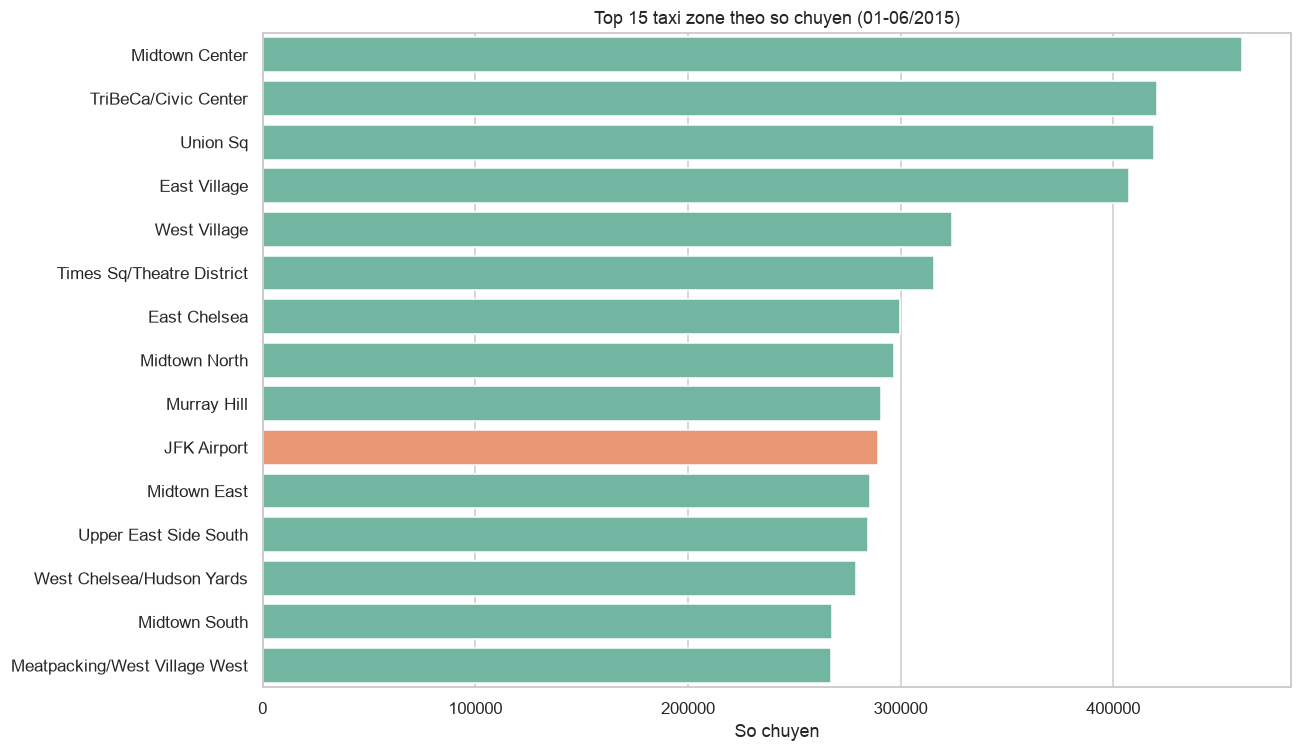

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=top15,
    y="Zone",
    x="trips",
    hue="Borough",
    ax=ax,
    palette="Set2",
    legend=False,
)
ax.set_title("Top 15 taxi zone theo so chuyen (01-06/2015)")
ax.set_xlabel("So chuyen")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_06_top_zones.png", bbox_inches="tight")
plt.show()

Ty le chuyen theo quan (2015):
Borough
Manhattan        72.67
Brooklyn         16.27
Queens            9.42
Bronx             1.54
Staten Island     0.05
Unknown           0.04
EWR               0.00
Name: share_pct, dtype: float64


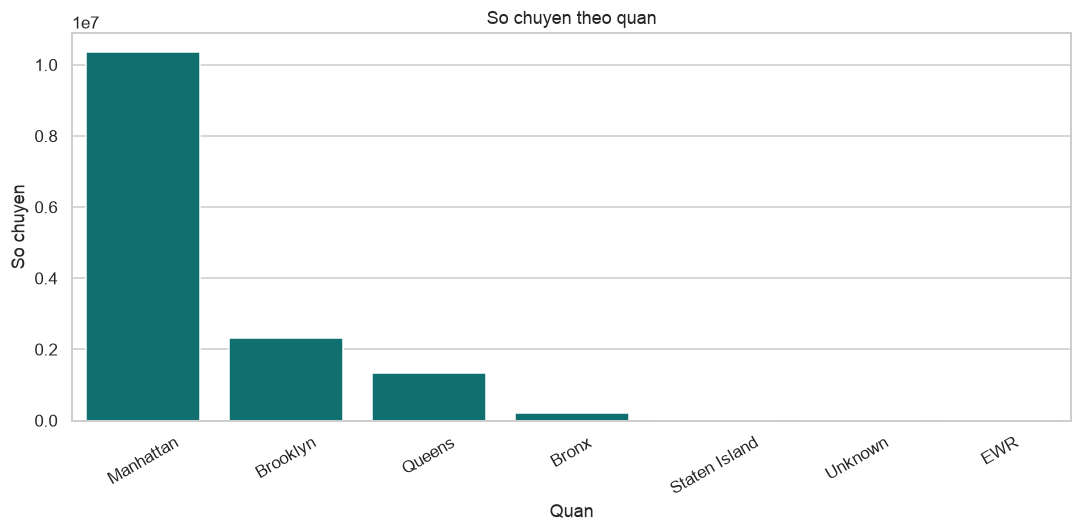

In [19]:
borough_share = (
    zone_counts.groupby("Borough")["trips"].sum().sort_values(ascending=False)
)
borough_share = borough_share[borough_share.index.notna()]
print("Ty le chuyen theo quan (2015):")
print(((borough_share / borough_share.sum() * 100).round(2)).rename("share_pct"))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=borough_share.index, y=borough_share.values, color="teal", ax=ax)
ax.set_title("So chuyen theo quan")
ax.set_xlabel("Quan")
ax.set_ylabel("So chuyen")
plt.setp(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

---

## 9. Chọn tham số DBSCAN từ dữ liệu (k-distance)

Đây là phần quan trọng nhất để `eps` và `MinPts` **có căn cứ** thay vì chọn theo cảm tính.

**Khoảng cách k-th nearest neighbor:** với mỗi điểm, tính khoảng cách tới điểm thứ k gần nhất rồi vẽ theo thứ tự. Chỗ đường cong **bẻ ngang** (elbow) là nơi điểm bắt đầu thuộc về một cụm thật — `eps` ứng với khoảng cách tại đó.

`MinPts = k` nghĩa là "một vùng là hotspot khi có ít nhất k chuyến đón trong bán kính eps" — diễn giải nghiệp vụ trực tiếp, đây là lý do chọn DBSCAN cho bài này.

> Với hàng triệu điểm, không thể tính kNN theo cặp. Dùng `sklearn.neighbors.NearestNeighbors` (cây KD-ball trong không gian phẳng UTM) trên một mẫu ngẫu nhiên 50k điểm.

In [20]:
# Chuyen lat/lon -> he phang tinh bang met.
#
# Da thu 3 phep chieu va do sai so thuc te (20000 cap ngau nhien):
#   equirectangular cos(lat0)      max ~0.18%   -> QUA nguong 0.5% khi gop ca 6 thang
#   equirectangular cos(lat)       max ~0.16%   -> van qua
#   azimuthal equidistant (sphere)  max ~0.00015% -> dung, gan nhu tuyet doi
# => chon azimuthal equidistant, tam tai trung tam kich thuoc tap diem.
LAT0, LON0 = clean["lat"].mean(), clean["lon"].mean()


def to_metric(lat, lon, lat0, lon0, radius=EARTH_R):
    """Chieu azimuthal equidistant (mat cau) sang he phang, don vi met."""
    la, lo, la0 = np.radians(lat), np.radians(lon - lon0), np.radians(lat0)
    cos_c = np.sin(la0) * np.sin(la) + np.cos(la0) * np.cos(la) * np.cos(lo)
    c = np.arccos(np.clip(cos_c, -1.0, 1.0))
    k = np.where(c < 1e-12, 1.0, c / np.sin(np.where(c < 1e-12, 1.0, c)))
    x = radius * k * np.cos(la) * np.sin(lo)
    y = radius * k * (np.cos(la0) * np.sin(la) - np.sin(la0) * np.cos(la) * np.cos(lo))
    return np.column_stack([x, y])


coords_m = to_metric(clean["lat"].to_numpy(), clean["lon"].to_numpy(), LAT0, LON0)
print("He toa do phang (met), tam tai:")
print(f"  lat0={LAT0:.5f}, lon0={LON0:.5f}")
# NumPy 2 da xoa ndarray.ptp() -> phai dung np.ptp()
print(f"  dai X: {np.ptp(coords_m[:, 0]) / 1000:.1f} km")
print(f"  dai Y: {np.ptp(coords_m[:, 1]) / 1000:.1f} km")

# KIEM CHUNG: khoang cach Euclid tren he phang phai khop haversine.
r = np.random.default_rng(RANDOM_SEED)
n = len(clean)
i, j = r.integers(0, n, 20000), r.integers(0, n, 20000)
d_true = haversine_m(clean["lat"].to_numpy()[i], clean["lon"].to_numpy()[i],
                     clean["lat"].to_numpy()[j], clean["lon"].to_numpy()[j])
d_proj = np.hypot(coords_m[i, 0] - coords_m[j, 0], coords_m[i, 1] - coords_m[j, 1])
# Chi kiem chung o khoang cach >= 100 m: du phong vi do chinh xac toa do
# lam sai so tuong doi nhay len khi hai diem gan nhau, trong khi thu do cua
# bai la thuoc dia 100 m.
far = d_true >= 100.0
rel_err = np.abs(d_proj[far] - d_true[far]) / d_true[far]
print()
print(f"Sai so tuong doi tren {far.sum():,} cap co khoang cach >= 100 m:")
print(f"  trung binh : {rel_err.mean() * 100:.6f}%")
print(f"  p99        : {np.percentile(rel_err, 99) * 100:.6f}%")
print(f"  max        : {rel_err.max() * 100:.6f}%")
assert rel_err.max() < 0.001, "phieu sai qua 0.1% - khong dung de tinh eps theo met"
print("  -> OK, dung de tinh eps theo met")

He toa do phang (met), tam tai:
  lat0=40.73869, lon0=-73.97422
  dai X: 47.1 km
  dai Y: 43.6 km

Sai so tuong doi tren 19,966 cap co khoang cach >= 100 m:
  trung binh : 0.000002%
  p99        : 0.000019%
  max        : 0.000124%
  -> OK, dung de tinh eps theo met


In [21]:
from sklearn.neighbors import NearestNeighbors

SAMPLE_N = 50_000
rng = np.random.default_rng(RANDOM_SEED)
idx = rng.choice(len(coords_m), size=SAMPLE_N, replace=False)
sample = coords_m[idx]

MAX_K = 30
nn = NearestNeighbors(n_neighbors=MAX_K + 1, metric="euclidean", n_jobs=-1)
nn.fit(sample)
dist, _ = nn.kneighbors(sample)
dist_sorted = np.sort(dist[:, 1:], axis=1)  # bo chinh diem dang xet
print("Khoang cach kNN (m) cua mau:", dist_sorted.shape)

Khoang cach kNN (m) cua mau: (50000, 30)


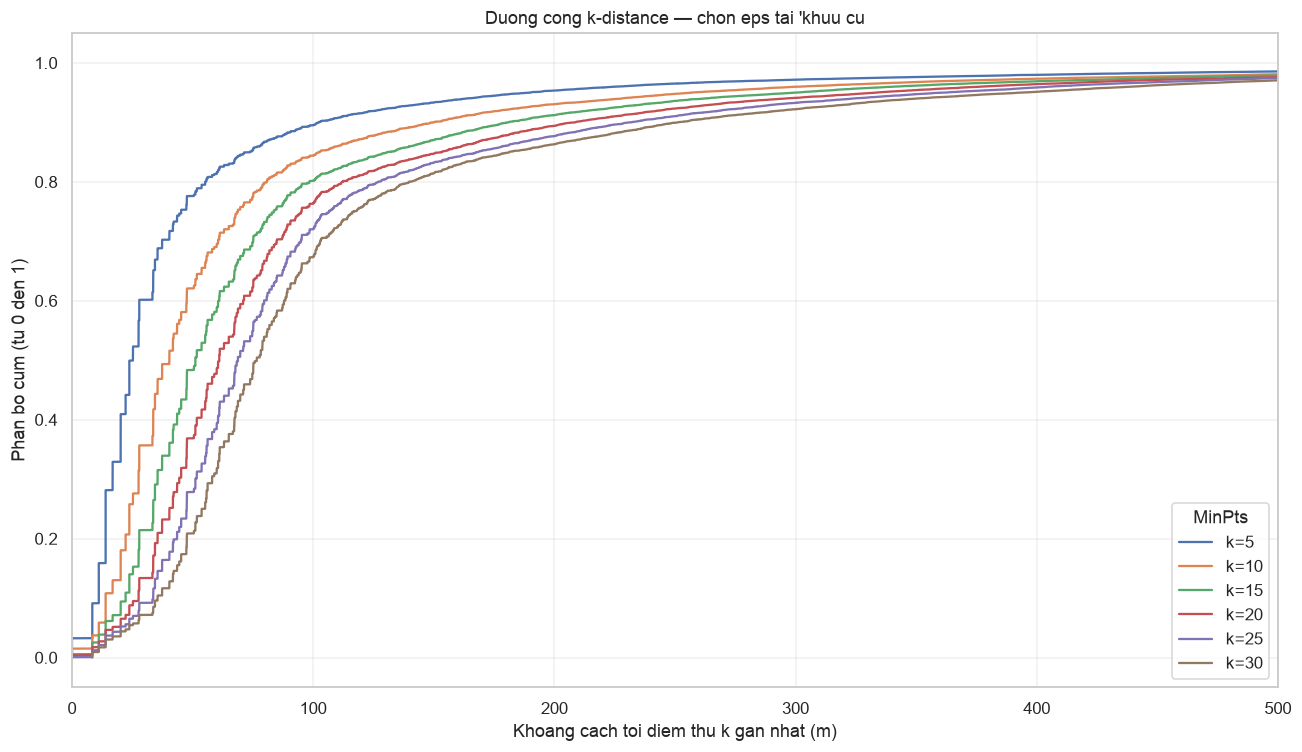

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))

K_LIST = [5, 10, 15, 20, 25, 30]
for k in K_LIST:
    d = dist_sorted[:, k - 1]
    d = d[d < 1000]  # bo diem quá xa, lam vo duong cong
    ax.plot(np.sort(d), np.arange(1, len(d) + 1) / len(d), label=f"k={k}")

ax.set_xlim(0, 500)
ax.set_xlabel("Khoang cach toi diem thu k gan nhat (m)")
ax.set_ylabel("Phan bo cum (tu 0 den 1)")
ax.set_title("Duong cong k-distance — chon eps tai 'khuu cu")
ax.legend(title="MinPts")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_07_kdistance.png", bbox_inches="tight")
plt.show()

In [23]:
# Diem khuyu: phan bo cum tai cac khoang cach uoc luong
rows = []
for eps_m in [30, 50, 75, 100, 150, 200, 300]:
    for k in [5, 10, 15, 20, 25, 30]:
        frac = (dist_sorted[:, k - 1] <= eps_m).mean()
        rows.append({"eps_m": eps_m, "MinPts": k, "ty_le_co_it_nhat_k_lan_can": round(frac, 4)})

grid = pd.DataFrame(rows).pivot(index="MinPts", columns="eps_m", values="ty_le_co_it_nhat_k_lan_can")
print("Ty le diem co it nhat k ban trong ban kinh eps")
print((grid * 100).round(1).astype(str) + "%")

Ty le diem co it nhat k ban trong ban kinh eps
eps_m     30     50     75     100    150    200    300
MinPts                                                 
5       59.8%  77.1%  84.8%  88.9%  92.7%  94.7%  96.5%
10      35.2%  61.3%  76.5%  83.4%  88.9%  91.9%  94.8%
15      21.0%  47.5%  68.6%  78.7%  85.5%  89.6%  93.3%
20      13.1%  36.0%  60.8%  74.6%  82.8%  87.4%  92.0%
25       9.0%  27.1%  53.4%  70.1%  81.0%  85.4%  90.8%
30       7.0%  20.3%  46.4%  65.4%  79.1%  83.8%  89.6%


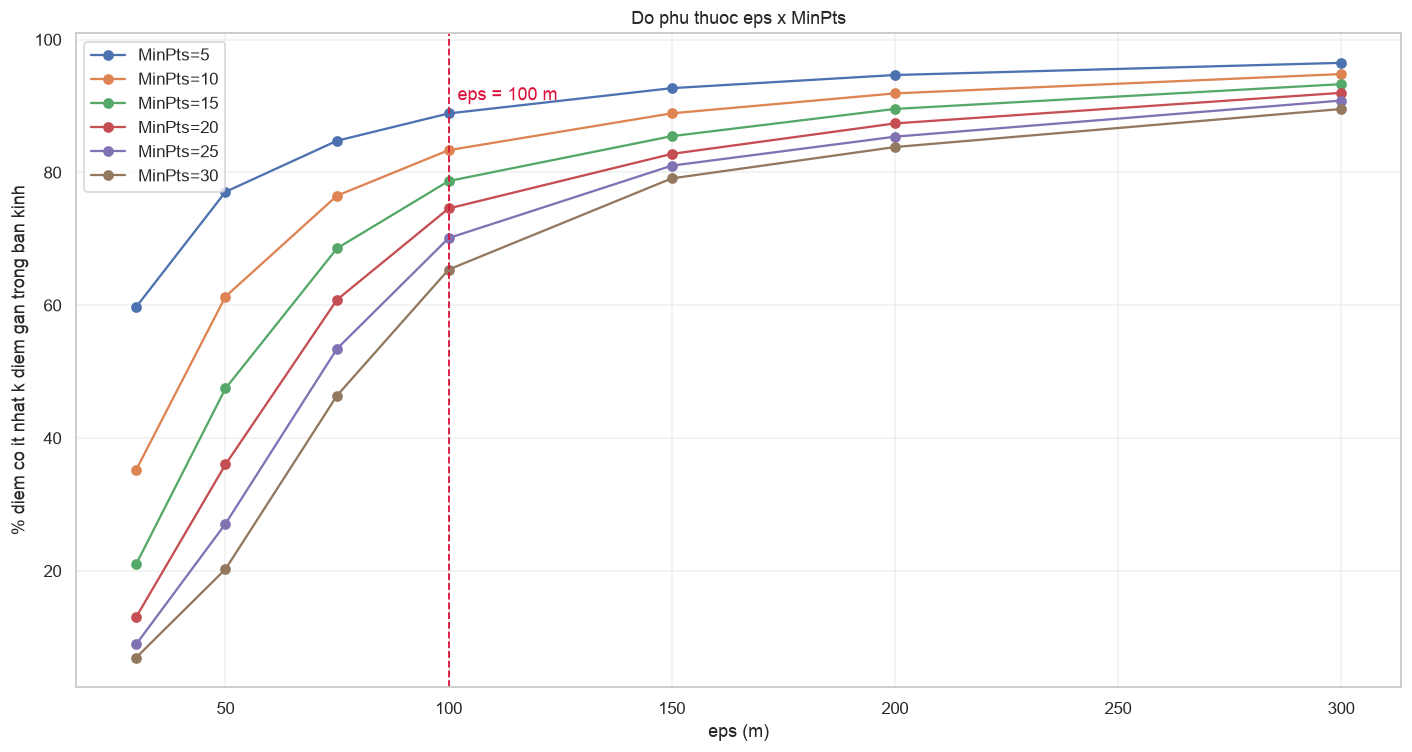

In [24]:
fig, ax = plt.subplots(figsize=(13, 7))
for k in K_LIST:
    ax.plot(grid.columns, grid.loc[k] * 100, marker="o", label=f"MinPts={k}")

ax.axvline(100, color="crimson", ls="--", lw=1.2)
ax.text(102, ax.get_ylim()[1] * 0.9, "eps = 100 m", color="crimson")
ax.set_xlabel("eps (m)")
ax.set_ylabel("% diem co it nhat k diem gan trong ban kinh")
ax.set_title("Do phu thuoc eps x MinPts")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 10. Chuẩn bị tập điểm cho clustering

DBSCAN phức tạp O(n·log n)–O(n²) tùy dữ liệu, chạy trên vài triệu điểm sẽ rất chậm và tốn RAM. Cách chuẩn bị hợp lý cho bài học:

- **Cắt khung giờ cao điểm** (ví dụ thứ 7, 17:00–19:00) → tập điểm nhỏ hơn nhiều lần.
- **Lọc theo bounding box Manhattan** nếu muốn tập trung vào khu vực chính.
- **Lấy mẫu ngẫu nhiên** nếu vẫn lớn, hoặc dùng `DBSCAN(min_samples=...)` để giảm nhạy với mẫu.

Dưới đây dựng sẵn bộ dữ liệu cho các ca khác nhau để notebook clustering dùng lại.

In [25]:
def make_frame(hour_range=(17, 19), dow=(5,), region=None, sample_n=None, seed=RANDOM_SEED):
    """Tao tap diem cho mot ca, tra ve (df, coords_m)."""
    h0, h1 = hour_range
    m = clean["hour"].between(h0, h1 - 1) & clean["dow"].isin(dow)
    sub = clean.loc[m]

    if region is not None:
        x0, y0, x1, y1 = region
        sub = sub[sub["lon"].between(x0, x1) & sub["lat"].between(y0, y1)]

    if sample_n and len(sub) > sample_n:
        sub = sub.iloc[np.random.default_rng(seed).choice(len(sub), sample_n, replace=False)]

    xy = to_metric(sub["lat"].to_numpy(), sub["lon"].to_numpy(), LAT0, LON0)
    return sub, xy


MANHATTAN = (-74.05, 40.68, -73.90, 40.85)

SCENARIOS = {
    "ca_diem_t7_toan_bo": dict(hour_range=(17, 19), dow=(5,)),
    "ca_diem_t7_manhattan": dict(hour_range=(17, 19), dow=(5,), region=MANHATTAN),
    "ca_sang_t2_manhattan": dict(hour_range=(8, 10), dow=(0,), region=MANHATTAN),
    "dem_thu7_manhattan": dict(hour_range=(0, 4), dow=(5,), region=MANHATTAN),
}

for name, kw in SCENARIOS.items():
    sub, xy = make_frame(**kw)
    print(f"{name:26s} n={len(sub):>9,}")
    print(f"{'':26s} dai X {np.ptp(xy[:, 0]) / 1000:5.1f} km | dai Y {np.ptp(xy[:, 1]) / 1000:5.1f} km")

ca_diem_t7_toan_bo         n=   87,810
                           dai X  46.9 km | dai Y  40.3 km
ca_diem_t7_manhattan       n=   78,066
                           dai X  12.6 km | dai Y  18.9 km
ca_sang_t2_manhattan       n=   43,781
                           dai X  12.6 km | dai Y  18.9 km


dem_thu7_manhattan         n=   62,900
                           dai X  12.6 km | dai Y  18.9 km


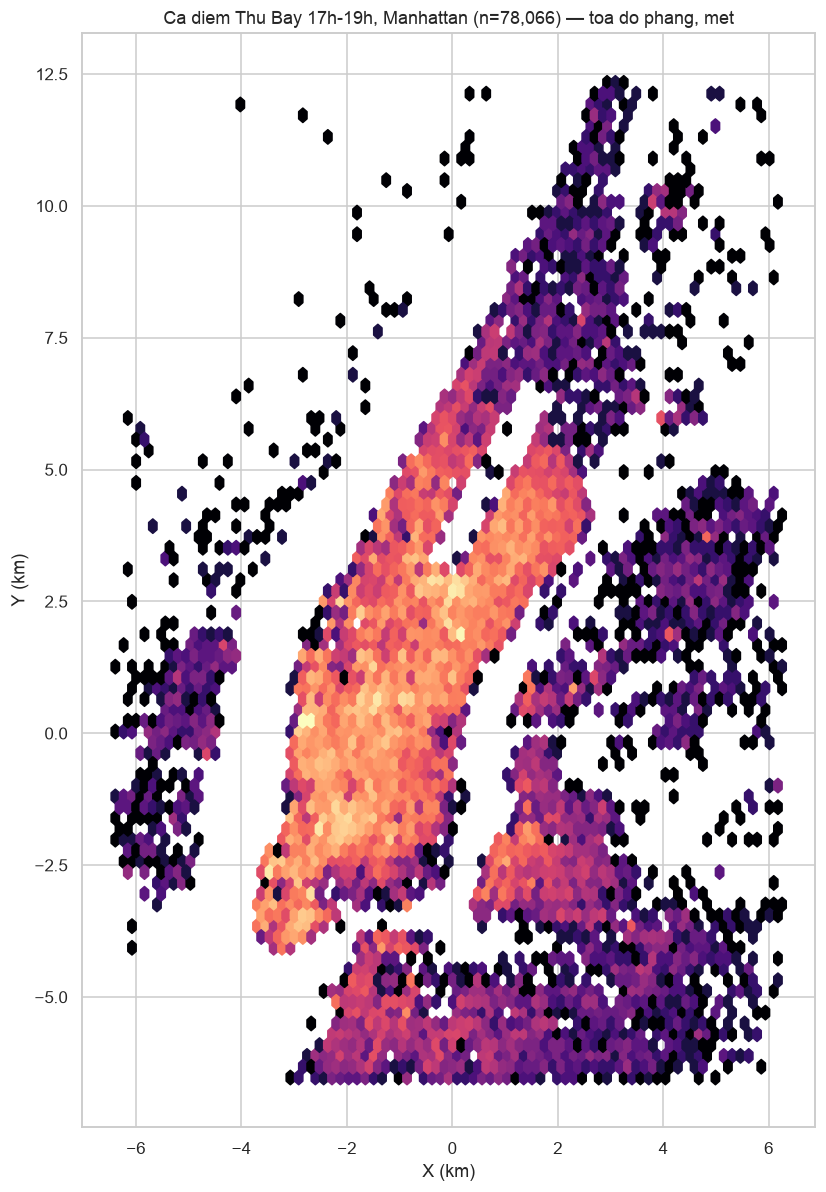

In [26]:
sub, xy = make_frame(**SCENARIOS["ca_diem_t7_manhattan"])

fig, ax = plt.subplots(figsize=(11, 11))
ax.hexbin(xy[:, 0] / 1000, xy[:, 1] / 1000, gridsize=80, cmap="magma", mincnt=1, bins="log")
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Ca diem Thu Bay 17h-19h, Manhattan (n={len(sub):,}) — toa do phang, met")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_08_peak_manhattan.png", bbox_inches="tight")
plt.show()

In [27]:
print(f"Bang tong hop kich thuoc tap diem:")
for name, kw in SCENARIOS.items():
    s, _ = make_frame(**kw)
    print(f"  {name:26s} {len(s):>9,} diem")

print()
print("Goi y cau hinh DBSCAN ban đầu:")
print("  eps = 100 (met)   — vua du khop o khu trung tam")
print("  min_samples = 15  — ~15 chuyen/100m moi coi la vung don")
print("  metric = euclidean tren toa do phang da doi sang met")

Bang tong hop kich thuoc tap diem:
  ca_diem_t7_toan_bo            87,810 diem
  ca_diem_t7_manhattan          78,066 diem
  ca_sang_t2_manhattan          43,781 diem
  dem_thu7_manhattan            62,900 diem

Goi y cau hinh DBSCAN ban đầu:
  eps = 100 (met)   — vua du khop o khu trung tam
  min_samples = 15  — ~15 chuyen/100m moi coi la vung don
  metric = euclidean tren toa do phang da doi sang met


---

## 11. Kết luận khảo sát

- Sáu file năm 2014 có khoảng 4,53 triệu lượt đón. Số lượt đón thay đổi theo giờ, thứ trong tuần và khu vực, nên các bước phân tích tiếp theo cần chọn rõ ngữ cảnh thời gian và không gian.
- Tọa độ thiếu, tọa độ `(0, 0)` và điểm ngoài phạm vi nghiên cứu cần được kiểm tra trước khi phân cụm. Một điểm ngoài phạm vi không nhất thiết là bản ghi sai; quy tắc lọc chính thức nằm trong `src/preprocess.py`.
- Khoảng cách trên kinh/vĩ độ dạng độ không tương đương khoảng cách mét. Dữ liệu cần được chiếu sang hệ tọa độ mét trước khi chạy DBSCAN với `eps` tính bằng mét.
- Phân bố k-distance giúp chọn các giá trị `eps` và `MinPts` để thử nghiệm. Kết quả khảo sát toàn bộ dữ liệu không xác lập một bộ tham số tối ưu cho mọi khu vực và khung giờ.
- Dữ liệu taxi zone năm 2015 chỉ được dùng để khảo sát thống kê theo vùng; nó không cung cấp tọa độ từng lượt đón cho quy trình DBSCAN của ứng dụng.